# Jour 2 — TP : mini-rapport exploratoire

## Consignes

**Travail en groupe, sur VOTRE dataset nettoyé au Jour 1** (celui de votre dépôt Git).

**Partie 1 — fin de matinée : réponses chiffrées**
Reprenez les questions métier formulées au Jour 1. Pour **au moins 3 d'entre elles**, produisez le tableau qui y répond (`groupby`, `agg`, `pivot_table`, nouvelles variables…) et rédigez une phrase de réponse chiffrée.

**Partie 2 — après-midi : le mini-rapport**
Transformez vos analyses en un mini-rapport de **5 à 8 visualisations commentées**, structuré comme un vrai livrable professionnel (modèle ci-dessous).

**Rendu** : ce notebook complété, qui s'exécute du début à la fin sans erreur (*Kernel → Restart & Run All*), commité et poussé sur Git **avant la fin de la journée**, avec un message explicite (ex. `J2 - mini-rapport exploratoire`).

## Ce qu'on attend de chaque analyse

**Question → tableau → graphique → commentaire en 3 temps** (constat chiffré, interprétation, suite).

Rappels du cours :
- un titre de graphique **énonce le message**, il ne décrit pas ;
- un taux global = **ratio des sommes**, pas moyenne des ratios ;
- `nunique` pour compter des clients, `count` pour des lignes ;
- une comparaison semaine / week-end se ramène au **nombre de jours**.

## Checklist avant de rendre

- [ ] Le notebook tourne du début à la fin après *Restart & Run All*
- [ ] Chaque graphique a un titre-message, des axes nommés et des unités
- [ ] Chaque graphique est suivi de son commentaire en 3 temps
- [ ] La synthèse en tête du rapport est rédigée (et cohérente avec les analyses)
- [ ] Le périmètre (filtres, période, règles métier) est indiqué
- [ ] Le code est commenté et les cellules inutiles supprimées
- [ ] Commit + push effectués

## Grille d'évaluation (sur 20)

| Critère | Points | Ce qu'on regarde |
|---|---|---|
| Pertinence métier | 4 | Les questions ont un vrai intérêt pour l'activité ; les réponses y répondent vraiment |
| Justesse des agrégations | 4 | Bons indicateurs, bons filtres, ratios bien calculés, pas de double comptage |
| Choix et lisibilité des graphiques | 5 | Type adapté à la question, titres-messages, axes et unités, tri, sobriété |
| Qualité des commentaires | 4 | Chiffrés, interprétés avec prudence, débouchant sur une suite concrète |
| Structure et reproductibilité | 3 | Notebook propre et ordonné, code commenté, exécution complète sans erreur, commit Git |
| *Bonus* | +1 | Un graphique Plotly interactif réellement utile |

---

# *Smash : Analyse des ventes et des leviers de performance*

**Groupe :** *Jacques Callewaert*

**Contexte et périmètre :** *Cette analyse porte sur les données commerciales de Smash issues des tables commandes, clients et produits.  
Les trois tables sont reliées à partir des identifiants client et produit afin de construire une table analytique au niveau des lignes de commande.  
Conformément à la règle métier, seules les commandes ayant le statut **« Livrée »** sont prises en compte dans le chiffre d'affaires.  
Les principaux indicateurs étudiés sont le chiffre d'affaires, la marge, le panier, les clients distincts, les catégories, les villes, les modes de paiement et les canaux d'acquisition.*

## Synthèse

*Synthèse*

*L'analyse met en évidence plusieurs différences importantes dans les performances commerciales de Smash. Le chiffre d'affaires est concentré sur certaines villes et catégories, tandis que l'activité évolue également au cours de la période étudiée. Les comportements sont différents selon le mode de paiement, le canal d'acquisition et la présence d'une remise. Enfin, l'analyse de la marge montre qu'un chiffre d'affaires élevé ne signifie pas systématiquement une rentabilité plus élevée. Ces résultats permettent d'identifier les segments sur lesquels Smash peut concentrer ses actions commerciales.*

## Préparation des données

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titleweight"] = "bold"

# CHARGEMENT DES DONNÉES


commandes = pd.read_csv(
    "smash/commandes.csv",
    parse_dates=["date_commande"]
)

clients = pd.read_csv(
    "smash/clients.csv",
    parse_dates=["date_inscription"]
)

produits = pd.read_csv(
    "smash/produits.csv"
)


# JOINTURES

df = (
    commandes
    .merge(produits, on="produit_id", how="left")
    .merge(clients, on="client_id", how="left")
)

# INDICATEURS MÉTIER


df["montant"] = (
    df["quantite"]
    * df["prix_unitaire"]
    * (1 - df["remise"])
)

df["cout"] = (
    df["quantite"]
    * df["cout_unitaire"]
)

df["marge"] = df["montant"] - df["cout"]

# Seules les commandes livrées entrent dans le CA
ventes = df[df["statut"] == "Livrée"].copy()

print(f"{len(df)} lignes au total")
print(f"{len(ventes)} lignes correspondant à des commandes livrées")
print(
    f"Période : {ventes['date_commande'].min().date()} "
    f"au {ventes['date_commande'].max().date()}"
)

6500 lignes au total
5886 lignes correspondant à des commandes livrées
Période : 2025-01-01 au 2025-12-31


In [5]:
COULEUR = "#4C72B0"
ACCENT = "#DD8452"
GRIS = "#BBBBBB"

def euros(x, pos=None):
    return f"{x:,.0f} €".replace(",", " ")

def propre(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", alpha=0.20)
    ax.set_axisbelow(True)

In [6]:
# Variables temporelles
ventes["annee"] = ventes["date_commande"].dt.year
ventes["mois_num"] = ventes["date_commande"].dt.month
ventes["mois"] = ventes["date_commande"].dt.to_period("M").astype(str)
ventes["trimestre"] = "T" + ventes["date_commande"].dt.quarter.astype(str)

# Tranches d'âge
ventes["tranche_age"] = pd.cut(
    ventes["age"],
    bins=[18, 25, 35, 50, 65, 100],
    labels=["18-25", "26-35", "36-50", "51-65", "66+"],
    include_lowest=True
)

# Semaine / week-end
ventes["week_end"] = ventes["date_commande"].dt.dayofweek >= 5
ventes["type_jour"] = np.where(
    ventes["week_end"],
    "Week-end",
    "Semaine"
)

# Présence d'une remise
ventes["avec_remise"] = np.where(
    ventes["remise"] > 0,
    "Avec remise",
    "Sans remise"
)

# Contrôles rapides
print("CA total :", round(ventes["montant"].sum(), 2), "€")
print("Marge totale :", round(ventes["marge"].sum(), 2), "€")
print("Clients distincts :", ventes["client_id"].nunique())

CA total : 642688.78 €
Marge totale : 232616.59 €
Clients distincts : 984


## Analyses

### Analyse 1 : Des performances commerciales inégales selon les villes

**Question métier :** Dans quelles villes Smash réalise-t-il le plus de chiffre d'affaires ?

**Indicateurs et périmètre :** chiffre d'affaires et nombre de lignes de commande, commandes livrées uniquement.

In [7]:
analyse_ville = (
    ventes.groupby("ville")
    .agg(
        ca=("montant", "sum"),
        nb_lignes=("commande_id", "count"),
        clients=("client_id", "nunique")
    )
    .sort_values("ca", ascending=False)
)

analyse_ville.round(2)

,ca,nb_lignes,clients
ville,,,
Paris,203716.77,1890,302
Marseille,76379.65,680,110
Lyon,73584.98,666,131
Toulouse,68493.09,592,102
Bordeaux,65984.71,598,88
Lille,54826.04,514,79
Strasbourg,50905.39,443,81
Nantes,48798.15,503,91


In [8]:
top_ville = analyse_ville.iloc[0]

print(
    f"{analyse_ville.index[0]} arrive en tête avec "
    f"{top_ville['ca']:,.2f} € de CA, "
    f"pour {int(top_ville['nb_lignes'])} lignes de commande."
)

Paris arrive en tête avec 203,716.77 € de CA, pour 1890 lignes de commande.


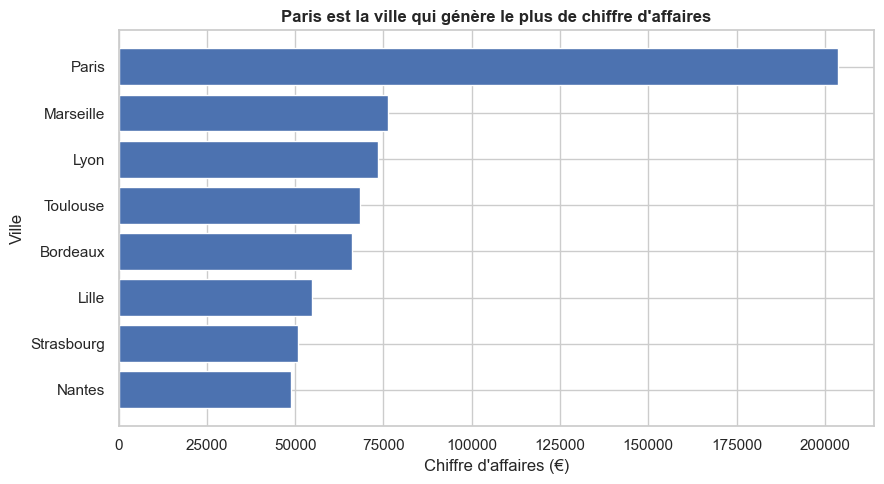

In [9]:
graph_ville = analyse_ville.sort_values("ca")

plt.figure(figsize=(9, 5))

plt.barh(
    graph_ville.index,
    graph_ville["ca"]
)

plt.title(
    f"{analyse_ville.index[0]} est la ville qui génère le plus de chiffre d'affaires"
)

plt.xlabel("Chiffre d'affaires (€)")
plt.ylabel("Ville")

plt.tight_layout()
plt.show()

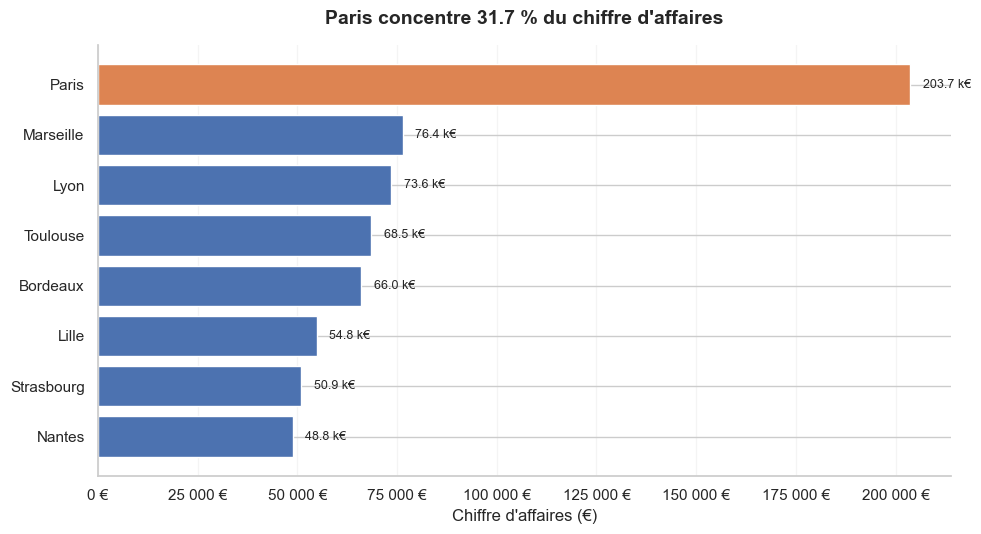

In [10]:
graph_ville = analyse_ville.sort_values("ca", ascending=True).copy()

ca_total = analyse_ville["ca"].sum()
ville_top = analyse_ville["ca"].idxmax()
ca_top = analyse_ville.loc[ville_top, "ca"]
part_top = ca_top / ca_total * 100

couleurs = [
    ACCENT if ville == ville_top else COULEUR
    for ville in graph_ville.index
]

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.barh(
    graph_ville.index,
    graph_ville["ca"],
    color=couleurs
)

for bar, valeur in zip(bars, graph_ville["ca"]):
    ax.text(
        valeur + ca_total * 0.005,
        bar.get_y() + bar.get_height()/2,
        f"{valeur/1000:.1f} k€",
        va="center",
        fontsize=9
    )

ax.set_title(
    f"{ville_top} concentre {part_top:.1f} % du chiffre d'affaires",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Chiffre d'affaires (€)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(euros))

propre(ax)
plt.tight_layout()
plt.show()

**Commentaire**
**Constat :** Paris arrive largement en tête du classement avec plus de 200 k€ de chiffre d’affaires, très loin devant Marseille et Lyon. Paris représente à elle seule une part importante du CA total de Smash.

**Interprétation :** cette concentration montre que les performances commerciales sont fortement dépendantes de la zone géographique. Il faut cependant vérifier si Paris domine parce qu’elle possède davantage de clients ou parce que ses clients dépensent davantage.

**Suite :** l’étape suivante serait de comparer le CA moyen par client et le nombre de clients par ville afin de distinguer un effet de volume d’un effet de valeur.

### Analyse 2 — Les catégories qui vendent le plus ne sont pas forcément les plus rentables

**Question métier :** Quelles catégories de produits contribuent le plus au chiffre d'affaires et à la marge ?

**Indicateurs et périmètre :** CA, marge totale, taux de marge et clients distincts, commandes livrées uniquement.

In [11]:
analyse_cat = (
    ventes.groupby("categorie")
    .agg(
        ca=("montant", "sum"),
        marge=("marge", "sum"),
        clients=("client_id", "nunique"),
        quantite=("quantite", "sum")
    )
)

# Ratio des sommes, et non moyenne de ratios
analyse_cat["taux_marge_pct"] = (
    analyse_cat["marge"]
    / analyse_cat["ca"]
    * 100
)

analyse_cat = analyse_cat.sort_values(
    "ca",
    ascending=False
)

analyse_cat.round(2)

,ca,marge,clients,quantite,taux_marge_pct
categorie,,,,,
Électronique,235386.18,44011.28,464,1400,18.70
Maison,125041.48,50533.36,529,1679,40.41
Mode,115364.18,61577.69,582,2159,53.38
Beauté,73928.10,43690.91,520,1631,59.10
Sport,64992.64,25683.27,474,1409,39.52
Livres,27976.21,7120.08,418,1510,25.45


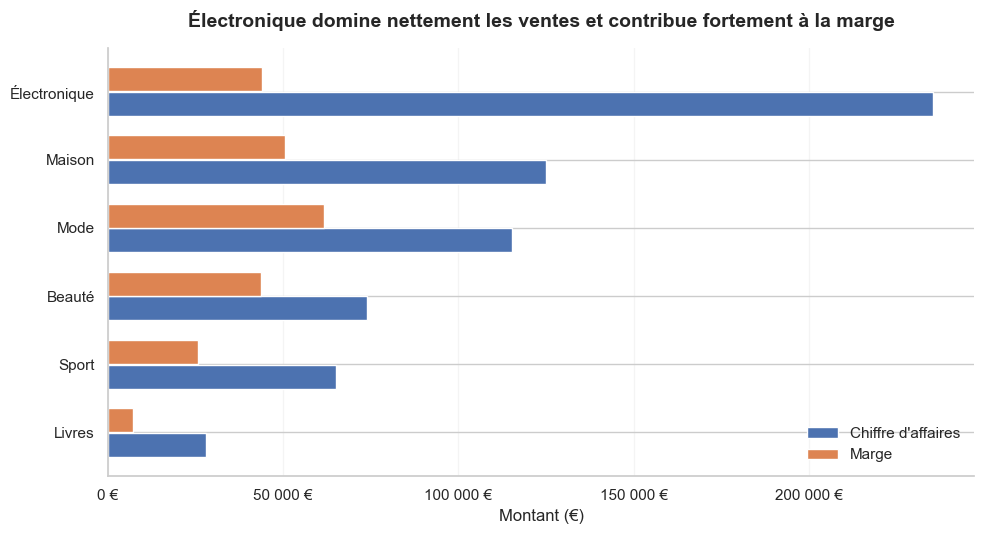

In [30]:
graph_cat = analyse_cat.sort_values("ca", ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 5.5))

y = range(len(graph_cat))

ax.barh(
    [i - 0.18 for i in y],
    graph_cat["ca"],
    height=0.35,
    label="Chiffre d'affaires",
    color=COULEUR
)

ax.barh(
    [i + 0.18 for i in y],
    graph_cat["marge"],
    height=0.35,
    label="Marge",
    color=ACCENT
)

ax.set_yticks(list(y))
ax.set_yticklabels(graph_cat.index)

cat_top = analyse_cat["ca"].idxmax()

ax.set_title(
    f"{cat_top} domine nettement les ventes et contribue fortement à la marge",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Montant (€)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(euros))
ax.legend(frameon=False)

propre(ax)
plt.tight_layout()
plt.show()

In [31]:
cat_top = analyse_cat["ca"].idxmax()

print(
    f"{cat_top} : "
    f"{analyse_cat.loc[cat_top, 'ca']:,.0f} € de CA, "
    f"{analyse_cat.loc[cat_top, 'marge']:,.0f} € de marge, "
    f"soit un taux de marge de "
    f"{analyse_cat.loc[cat_top, 'taux_marge_pct']:.1f} %."
)

Électronique : 235,386 € de CA, 44,011 € de marge, soit un taux de marge de 18.7 %.


**Commentaire**

**Constat :** l'électronique domine très nettement le classement, avec environ deux fois plus de chiffre d’affaires que plusieurs catégories intermédiaires. L’analyse de la marge permet en parallèle de vérifier que cette forte activité se traduit bien par de la valeur pour Smash.

**Interprétation :** le poids d’une catégorie ne doit pas être jugé uniquement sur ses ventes. Une catégorie peut générer beaucoup de CA mais être moins intéressante si ses coûts ou ses remises réduisent fortement sa marge.

**Suite :** Smash pourrait comparer le taux de marge et le nombre de clients de chaque catégorie afin d’identifier les produits à la fois populaires et rentables.

### Analyse 3 — L'activité varie sensiblement au cours de la période

**Question métier :** Comment le chiffre d'affaires évolue-t-il mois après mois ?

**Indicateurs et périmètre :** chiffre d'affaires mensuel en k€, commandes livrées uniquement.

In [13]:
analyse_mois = (
    ventes
    .groupby("mois", as_index=False)
    .agg(
        ca=("montant", "sum"),
        nb_commandes=("commande_id", "nunique")
    )
)

analyse_mois["ca_ke"] = analyse_mois["ca"] / 1000

analyse_mois.round(2)

,mois,ca,nb_commandes,ca_ke
0,2025-01,45674.18,419,45.67
1,2025-02,33999.83,317,34.00
2,2025-03,48192.44,442,48.19
3,2025-04,45653.89,432,45.65
4,2025-05,50660.60,460,50.66
5,2025-06,47219.50,449,47.22
6,2025-07,43367.99,377,43.37
7,2025-08,27476.65,296,27.48
8,2025-09,50165.73,442,50.17
9,2025-10,56791.02,502,56.79


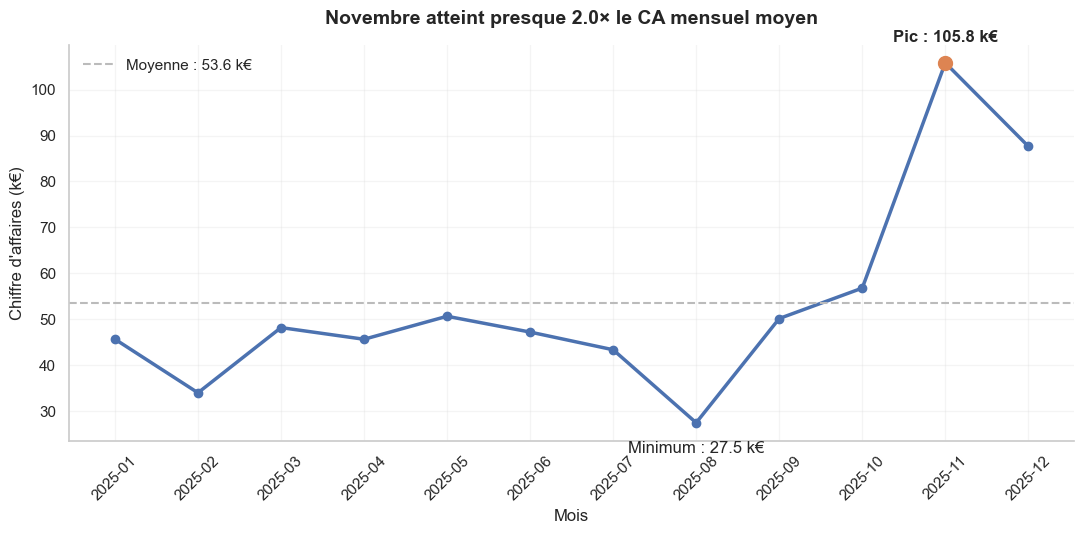

In [32]:
moyenne = analyse_mois["ca_ke"].mean()

max_row = analyse_mois.loc[analyse_mois["ca_ke"].idxmax()]
min_row = analyse_mois.loc[analyse_mois["ca_ke"].idxmin()]

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(
    analyse_mois["mois"],
    analyse_mois["ca_ke"],
    marker="o",
    linewidth=2.5,
    color=COULEUR
)

ax.axhline(
    moyenne,
    linestyle="--",
    color=GRIS,
    label=f"Moyenne : {moyenne:.1f} k€"
)

# Point maximum
ax.scatter(
    max_row["mois"],
    max_row["ca_ke"],
    s=100,
    color=ACCENT,
    zorder=5
)

ax.annotate(
    f"Pic : {max_row['ca_ke']:.1f} k€",
    (max_row["mois"], max_row["ca_ke"]),
    xytext=(0, 15),
    textcoords="offset points",
    ha="center",
    fontweight="bold"
)

# Point minimum
ax.annotate(
    f"Minimum : {min_row['ca_ke']:.1f} k€",
    (min_row["mois"], min_row["ca_ke"]),
    xytext=(0, -22),
    textcoords="offset points",
    ha="center"
)

ratio_pic = max_row["ca_ke"] / moyenne

ax.set_title(
    f"Novembre atteint presque {ratio_pic:.1f}× le CA mensuel moyen",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Mois")
ax.set_ylabel("Chiffre d'affaires (k€)")
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.20)

plt.tight_layout()
plt.show()

In [15]:
meilleur_mois = analyse_mois.loc[
    analyse_mois["ca"].idxmax()
]

moins_bon_mois = analyse_mois.loc[
    analyse_mois["ca"].idxmin()
]

print(
    f"Le mois le plus performant est {meilleur_mois['mois']} "
    f"avec {meilleur_mois['ca']:,.2f} € de CA."
)

print(
    f"Le mois le moins performant est {moins_bon_mois['mois']} "
    f"avec {moins_bon_mois['ca']:,.2f} €."
)

Le mois le plus performant est 2025-11 avec 105,834.91 € de CA.
Le mois le moins performant est 2025-08 avec 27,476.65 €.


**Commentaire**


**Constat :** le CA mensuel moyen est d’environ 53,6 k€. Novembre constitue un pic exceptionnel avec 105,8 k€, soit presque deux fois la moyenne mensuelle, tandis qu’août atteint seulement 27,5 k€.

**Interprétation :** l’activité semble présenter une forte saisonnalité en fin d’année, avec une accélération dès octobre puis un pic en novembre. À l’inverse, août apparaît comme une période creuse.

**Suite :** il faudrait comparer le nombre de commandes, le panier moyen et le niveau de remise de novembre afin de déterminer si ce pic provient d’un volume supérieur, de paniers plus élevés ou d’actions promotionnelles.

### Analyse 4 — Le comportement d'achat varie selon le mode de paiement

**Question métier :** Les clients dépensent-ils le même montant selon leur mode de paiement ?

**Indicateurs et périmètre :** CA, panier moyen, panier médian, nombre de commandes et clients distincts.

In [16]:
analyse_paiement = (
    ventes.groupby("mode_paiement")
    .agg(
        ca=("montant", "sum"),
        nb_commandes=("commande_id", "nunique"),
        panier_moyen=("montant", "mean"),
        panier_median=("montant", "median"),
        clients=("client_id", "nunique")
    )
    .sort_values("panier_moyen", ascending=False)
)

analyse_paiement.round(2)

,ca,nb_commandes,panier_moyen,panier_median,clients
mode_paiement,,,,,
Paiement en 3x,131745.88,871,151.26,88.28,472
Virement,31384.77,301,104.27,63.76,231
PayPal,123410.03,1211,101.91,63.95,560
Carte bancaire,356148.10,3503,101.67,63.95,863


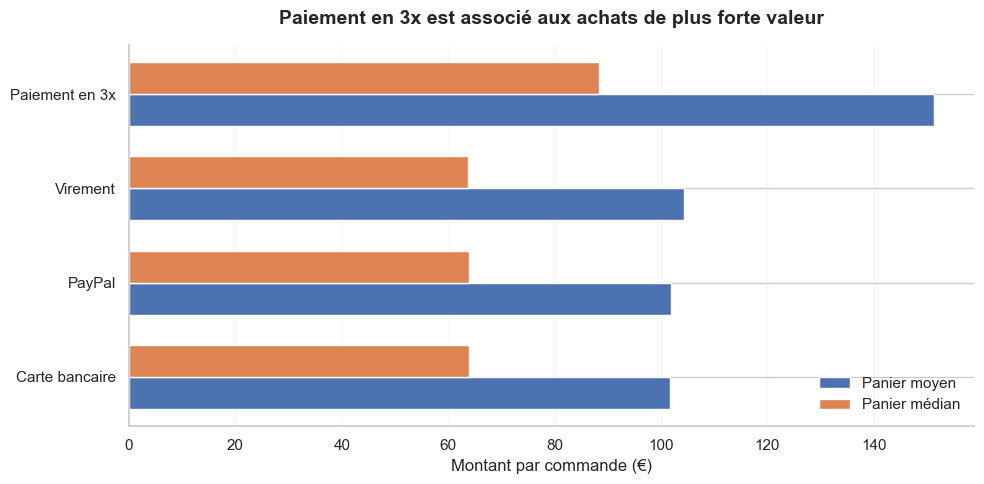

In [33]:
graph_paiement = analyse_paiement.sort_values(
    "panier_moyen",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 5))

y = range(len(graph_paiement))

ax.barh(
    [i - 0.17 for i in y],
    graph_paiement["panier_moyen"],
    height=0.34,
    color=COULEUR,
    label="Panier moyen"
)

ax.barh(
    [i + 0.17 for i in y],
    graph_paiement["panier_median"],
    height=0.34,
    color=ACCENT,
    label="Panier médian"
)

ax.set_yticks(list(y))
ax.set_yticklabels(graph_paiement.index)

meilleur = analyse_paiement["panier_moyen"].idxmax()

ax.set_title(
    f"{meilleur} est associé aux achats de plus forte valeur",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Montant par commande (€)")
ax.set_ylabel("")
ax.legend(frameon=False)

propre(ax)
plt.tight_layout()
plt.show()

In [18]:
meilleur_mode = analyse_paiement.index[0]

print(
    f"{meilleur_mode} présente le panier moyen le plus élevé : "
    f"{analyse_paiement.loc[meilleur_mode, 'panier_moyen']:.2f} €."
)

Paiement en 3x présente le panier moyen le plus élevé : 151.26 €.


**Commentaire**

**Constat :** le paiement en 3x se distingue nettement avec un panier moyen de 151,26 €, alors que les autres modes se situent autour de 100 €. La comparaison avec la médiane permet de vérifier si cette différence concerne l’ensemble des commandes ou seulement quelques achats très élevés.

**Interprétation :** le paiement fractionné semble davantage utilisé pour les achats importants, probablement parce qu’il facilite le financement de paniers plus coûteux. Il s’agit toutefois d’une association et non d’une preuve de causalité.

**Suite :** il serait pertinent de comparer les catégories achetées avec chaque mode de paiement : le panier élevé du 3x pourrait par exemple être lié à une utilisation plus fréquente pour l’Électronique.

### Analyse 5 — Les commandes remisées sont-elles réellement plus intéressantes ?

**Question métier :** Les commandes bénéficiant d'une remise présentent-elles un panier et une marge différents ?

**Indicateurs et périmètre :** nombre de commandes, panier moyen, CA et marge moyenne selon la présence ou non d'une remise.

In [19]:
analyse_remise = (
    ventes.groupby("avec_remise")
    .agg(
        nb_commandes=("commande_id", "nunique"),
        ca=("montant", "sum"),
        panier_moyen=("montant", "mean"),
        marge_moyenne=("marge", "mean"),
        marge_totale=("marge", "sum")
    )
)

analyse_remise.round(2)

,nb_commandes,ca,panier_moyen,marge_moyenne,marge_totale
avec_remise,,,,,
Avec remise,1894,185119.16,97.74,27.29,51695.70
Sans remise,3992,457569.62,114.62,45.32,180920.89


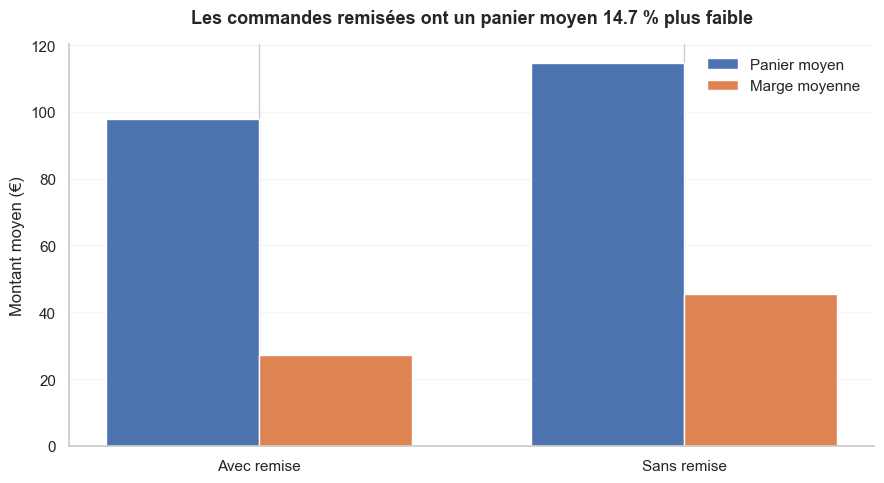

In [34]:
graph_remise = analyse_remise.copy()

fig, ax = plt.subplots(figsize=(9, 5))

y = range(len(graph_remise))

ax.bar(
    [i - 0.18 for i in y],
    graph_remise["panier_moyen"],
    width=0.36,
    label="Panier moyen",
    color=COULEUR
)

ax.bar(
    [i + 0.18 for i in y],
    graph_remise["marge_moyenne"],
    width=0.36,
    label="Marge moyenne",
    color=ACCENT
)

ax.set_xticks(list(y))
ax.set_xticklabels(graph_remise.index)

panier_remise = analyse_remise.loc["Avec remise", "panier_moyen"]
panier_sans = analyse_remise.loc["Sans remise", "panier_moyen"]

ecart_remise = (
    (panier_remise - panier_sans)
    / panier_sans
    * 100
)

ax.set_title(
    f"Les commandes remisées ont un panier moyen {abs(ecart_remise):.1f} % "
    f"{'plus faible' if ecart_remise < 0 else 'plus élevé'}",
    fontsize=13,
    pad=15
)

ax.set_ylabel("Montant moyen (€)")
ax.set_xlabel("")
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.20)

plt.tight_layout()
plt.show()

In [21]:
part_remise = (
    (ventes["remise"] > 0).sum()
    / len(ventes)
    * 100
)

print(
    f"{part_remise:.1f} % des lignes de vente bénéficient d'une remise."
)

32.2 % des lignes de vente bénéficient d'une remise.


**Commentaire**

**Constat :** 32,2 % des lignes de vente bénéficient d’une remise. Pourtant, le panier moyen des ventes avec remise est inférieur à celui des ventes sans remise : environ 97 € contre 114 € sur le graphique.

**Interprétation :** dans ces données, les remises ne sont donc pas associées à des paniers plus élevés. Elles peuvent servir à déclencher certains achats, mais elles réduisent le prix encaissé et peuvent également dégrader la marge.

**Suite :** il faudrait comparer le volume vendu et la marge par catégorie avant de conclure sur leur efficacité. Une remise peut être pertinente sur un produit à forte marge mais beaucoup moins sur un produit déjà peu rentable.

### Analyse 6 — Tous les canaux d'acquisition n'apportent pas la même valeur client

**Question métier :** Quels canaux d'acquisition apportent les clients ayant la plus forte valeur ?

**Indicateurs et périmètre :** nombre de clients, CA moyen par client, commandes moyennes par client et panier moyen.

In [22]:
par_client = (
    ventes.groupby(
        ["client_id", "canal_acquisition"],
        as_index=False
    )
    .agg(
        ca_client=("montant", "sum"),
        nb_commandes=("commande_id", "nunique")
    )
)

par_client["panier_moyen_client"] = (
    par_client["ca_client"]
    / par_client["nb_commandes"]
)

par_client.head()

,client_id,canal_acquisition,ca_client,nb_commandes,panier_moyen_client
0,C0001,Publicité en ligne,2435.996,17,143.293882
1,C0002,Moteur de recherche,58.743,1,58.743000
2,C0004,Publicité en ligne,133.620,1,133.620000
3,C0005,Bouche-à-oreille,333.201,4,83.300250
4,C0006,Publicité en ligne,92.620,2,46.310000


In [23]:
analyse_canal = (
    par_client.groupby("canal_acquisition")
    .agg(
        nb_clients=("client_id", "nunique"),
        ca_moyen_client=("ca_client", "mean"),
        commandes_moyennes=("nb_commandes", "mean"),
        panier_moyen=("panier_moyen_client", "mean")
    )
    .sort_values("ca_moyen_client", ascending=False)
)

analyse_canal.round(2)

,nb_clients,ca_moyen_client,commandes_moyennes,panier_moyen
canal_acquisition,,,,
Moteur de recherche,302,686.98,5.98,111.80
Bouche-à-oreille,116,673.08,6.02,120.24
Réseaux sociaux,368,644.56,6.06,107.25
Publicité en ligne,198,605.78,5.81,98.74


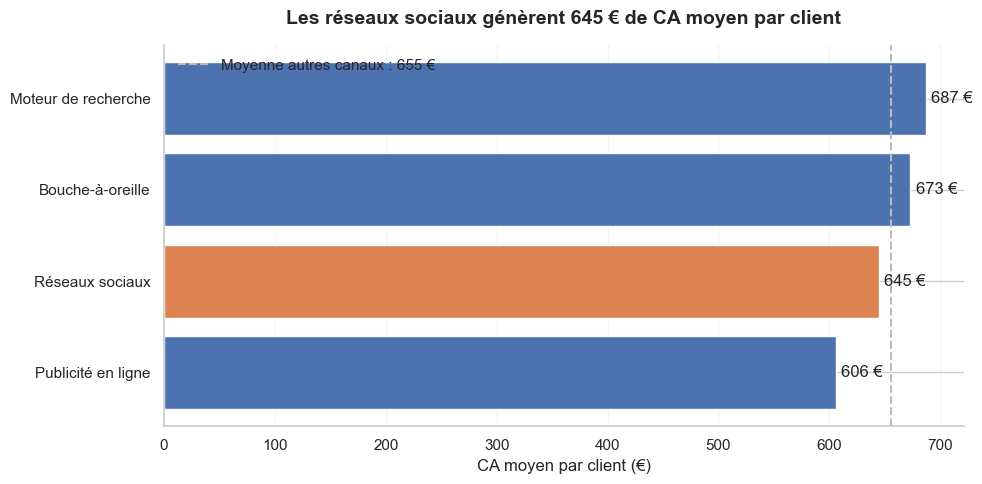

In [35]:
graph_canal = analyse_canal.sort_values(
    "ca_moyen_client",
    ascending=True
)

couleurs = [
    ACCENT if canal == "Réseaux sociaux" else COULEUR
    for canal in graph_canal.index
]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    graph_canal.index,
    graph_canal["ca_moyen_client"],
    color=couleurs
)

for bar, valeur in zip(bars, graph_canal["ca_moyen_client"]):
    ax.text(
        valeur + 5,
        bar.get_y() + bar.get_height()/2,
        f"{valeur:.0f} €",
        va="center"
    )

social = analyse_canal.loc[
    "Réseaux sociaux",
    "ca_moyen_client"
]

autres = analyse_canal.loc[
    analyse_canal.index != "Réseaux sociaux",
    "ca_moyen_client"
].mean()

ecart_social = (social / autres - 1) * 100

ax.axvline(
    autres,
    linestyle="--",
    color=GRIS,
    label=f"Moyenne autres canaux : {autres:.0f} €"
)

ax.set_title(
    f"Les réseaux sociaux génèrent {social:.0f} € de CA moyen par client",
    fontsize=14,
    pad=15
)

ax.set_xlabel("CA moyen par client (€)")
ax.set_ylabel("")
ax.legend(frameon=False)

propre(ax)
plt.tight_layout()
plt.show()

In [25]:
meilleur_canal = analyse_canal.index[0]

print(
    f"Le canal {meilleur_canal} présente le CA moyen par client "
    f"le plus élevé avec "
    f"{analyse_canal.loc[meilleur_canal, 'ca_moyen_client']:.2f} €."
)

Le canal Moteur de recherche présente le CA moyen par client le plus élevé avec 686.98 €.


**Commentaire**

**Constat :** les clients issus des réseaux sociaux génèrent environ 645 € de CA moyen, ce qui les place derrière le moteur de recherche (686,98 €) et légèrement derrière le bouche-à-oreille, mais devant la publicité en ligne.

**Interprétation :** les réseaux sociaux apportent donc des clients de bonne valeur, sans être le canal le plus performant. Le moteur de recherche semble produire les clients les plus intéressants en valeur moyenne.

**Suite :** cette comparaison doit être complétée par le coût d’acquisition de chaque canal. Un canal avec 650 € de CA/client peut être plus rentable qu’un canal à 687 € s'il coûte beaucoup moins cher pour acquérir un client.

### Analyse 7 — L'activité quotidienne diffère-t-elle entre semaine et week-end ?

**Question métier :** Smash génère-t-il davantage de chiffre d'affaires par jour en semaine ou le week-end ?

**Indicateurs et périmètre :** CA quotidien moyen et commandes quotidiennes moyennes, commandes livrées uniquement.

In [26]:
ca_journalier = (
    ventes.groupby(
        ventes["date_commande"].dt.date
    )
    .agg(
        ca=("montant", "sum"),
        nb_commandes=("commande_id", "nunique")
    )
    .reset_index()
)

ca_journalier["date_commande"] = pd.to_datetime(
    ca_journalier["date_commande"]
)

ca_journalier["type_jour"] = np.where(
    ca_journalier["date_commande"].dt.dayofweek >= 5,
    "Week-end",
    "Semaine"
)

In [27]:
analyse_jour = (
    ca_journalier.groupby("type_jour")
    .agg(
        nb_jours=("date_commande", "count"),
        ca_moyen_jour=("ca", "mean"),
        commandes_moyennes_jour=("nb_commandes", "mean")
    )
)

analyse_jour.round(2)

,nb_jours,ca_moyen_jour,commandes_moyennes_jour
type_jour,,,
Semaine,261,1717.54,15.20
Week-end,104,1869.34,18.46


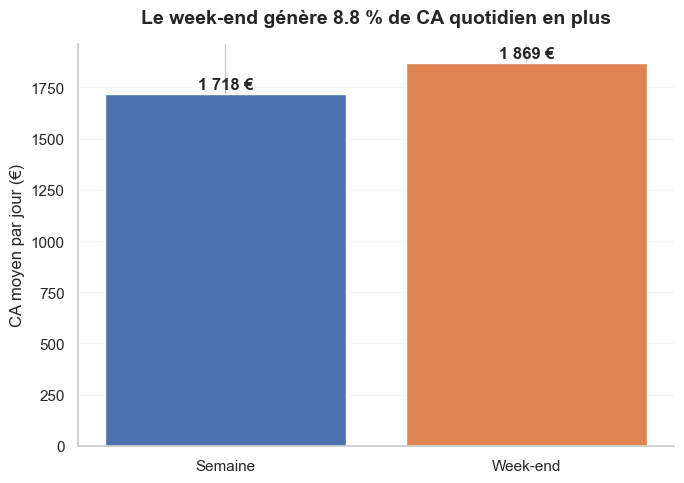

In [36]:
semaine = analyse_jour.loc["Semaine", "ca_moyen_jour"]
weekend = analyse_jour.loc["Week-end", "ca_moyen_jour"]

ecart_weekend = (
    (weekend / semaine) - 1
) * 100

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["Semaine", "Week-end"],
    [semaine, weekend],
    color=[COULEUR, ACCENT]
)

for bar, valeur in zip(bars, [semaine, weekend]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        valeur + 25,
        f"{valeur:,.0f} €".replace(",", " "),
        ha="center",
        fontweight="bold"
    )

ax.set_title(
    f"Le week-end génère {ecart_weekend:.1f} % de CA quotidien "
    f"{'en plus' if ecart_weekend >= 0 else 'en moins'}",
    fontsize=14,
    pad=15
)

ax.set_ylabel("CA moyen par jour (€)")
ax.set_xlabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.20)

plt.tight_layout()
plt.show()

**Commentaires**

**Constat :** une fois le chiffre d'affaires ramené à une journée comparable, le week-end génère davantage de CA que les jours de semaine, avec environ 1,85 k€ par jour contre 1,70 k€.

**Interprétation :** regarder uniquement le CA total aurait masqué ce phénomène, puisque la semaine contient beaucoup plus de jours que le week-end. En moyenne quotidienne, le week-end semble donc être une période commercialement plus performante.

**Suite :** utiliser les jours de sa sameine permettrait d'identifier si cette performance provient surtout du samedi, du dimanche ou des deux.

#### **Bonus Plotly interactif**

In [37]:
plotly_canal = analyse_canal.reset_index()

fig = px.scatter(
    plotly_canal,
    x="nb_clients",
    y="ca_moyen_client",
    text="canal_acquisition",
    hover_name="canal_acquisition",
    hover_data={
        "nb_clients": True,
        "ca_moyen_client": ":.2f",
        "commandes_moyennes": ":.2f",
        "panier_moyen": ":.2f"
    },
    labels={
        "nb_clients": "Nombre de clients",
        "ca_moyen_client": "CA moyen par client (€)",
        "commandes_moyennes": "Commandes moyennes / client",
        "panier_moyen": "Panier moyen (€)"
    },
    title="Acquisition : volume de clients et valeur client ne racontent pas la même chose"
)

fig.update_traces(
    marker=dict(size=16),
    textposition="top center"
)

fig.add_hline(
    y=plotly_canal["ca_moyen_client"].mean(),
    line_dash="dash",
    annotation_text="CA/client moyen"
)

fig.add_vline(
    x=plotly_canal["nb_clients"].mean(),
    line_dash="dash",
    annotation_text="Nb clients moyen"
)

fig.update_layout(
    height=550
)

fig.show()

## Limites et pistes pour le Jour 3


### Limites

- L'analyse porte uniquement sur les commandes livrées pour les indicateurs de chiffre d'affaires.
- Les relations observées sont descriptives et ne permettent pas d'établir directement une causalité.
- Certaines catégories, villes ou tranches de clients peuvent contenir moins d'observations que d'autres.
- Le chiffre d'affaires ne suffit pas à mesurer la performance : la marge doit également être prise en compte.
- Les performances des canaux d'acquisition sont analysées sans information sur leur coût marketing.

### Pistes

- Étudier plus précisément le lien entre remise, volume de ventes et marge.
- Construire une segmentation des clients selon leur valeur et leur fréquence d'achat.
- Analyser la fidélisation et le taux de réachat.
- Étudier la saisonnalité par catégorie de produit.
- Ajouter les coûts d'acquisition afin de comparer la rentabilité réelle des canaux marketing.